# Principle Component Analysis

### Creating dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mean_vec1 = np.array([0,0,0])  # Vector of mean of N-dimensions
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])  # Covariance matrix
class1_sample = np.random.multivariate_normal(mean_vec1, cov_mat1, 20)  # needed to provide mean vector, and covariance matrix

df1 = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df1['target'] = 1

mean_vec2 = np.array([1,1,1])  # Vector of mean of N-dimensions
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])  # Covariance matrix
class2_sample = np.random.multivariate_normal(mean_vec2, cov_mat2, 20)

df2 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df2['target'] = 0

df = pd.concat([df1, df2], ignore_index=True)

df = df.sample(40)  # It gives the randomness in the DataFrame

In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [3]:
df.shape

(40, 4)

In [4]:
df.mean()

feature1    0.433721
feature2    0.460790
feature3    0.667670
target      0.500000
dtype: float64

In [5]:
df.std()

feature1    1.157915
feature2    1.060976
feature3    1.152079
target      0.506370
dtype: float64

### Visualizing dataset

#### Using plotly

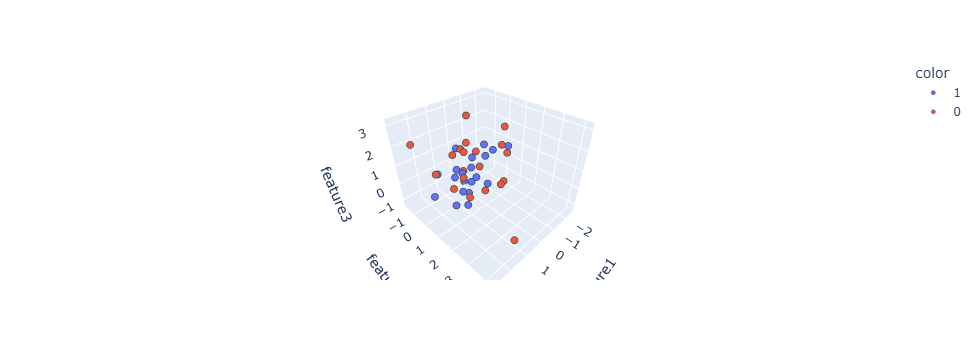

In [6]:
import plotly.express as px
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))  # .astype('str') changes the output int [0,1] to string
fig.update_traces(marker=dict(size=4,  # Size of bubble
                              line=dict(width=0.5,  # Border size of bubble
                                        color='DarkSlateGrey')),  # Border color of bubble
                  selector=dict(mode='markers'))  # can be 'lines', 'lines+markers'

fig.show()

#### Using Matplotlib

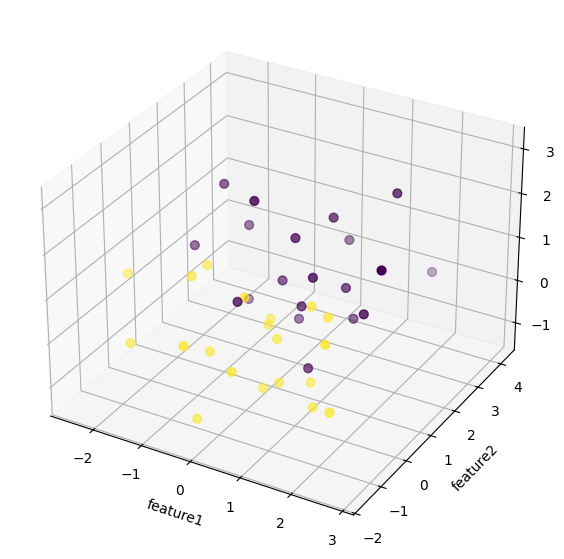

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    c=df['target'],
    s=40
)

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.show()

### Step 1 - Making data mean centered

In [22]:
# Step 1 - Apply standard scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [9]:
df.mean()

feature1    2.220446e-17
feature2    2.386980e-16
feature3   -1.453915e-16
target      5.000000e-01
dtype: float64

In [11]:
df.std(ddof=0)  # Delta Degree of Freedom(.../N-ddof)

feature1    1.0
feature2    1.0
feature3    1.0
target      0.5
dtype: float64

### Step 2 - Finding Covariance Matrix

In [41]:
cov_mat = df.iloc[:,:3].cov()
# covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])

In [42]:
print('Covariance Matrix:')
cov_mat

Covariance Matrix:


,feature1,feature2,feature3
feature1,1.025641,0.204781,0.080118
feature2,0.204781,1.025641,0.198389
feature3,0.080118,0.198389,1.025641


### Step 3- Finding eigenvalues, and eigen vector

In [43]:
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

In [44]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [45]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

### Visualising eigenvectors

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


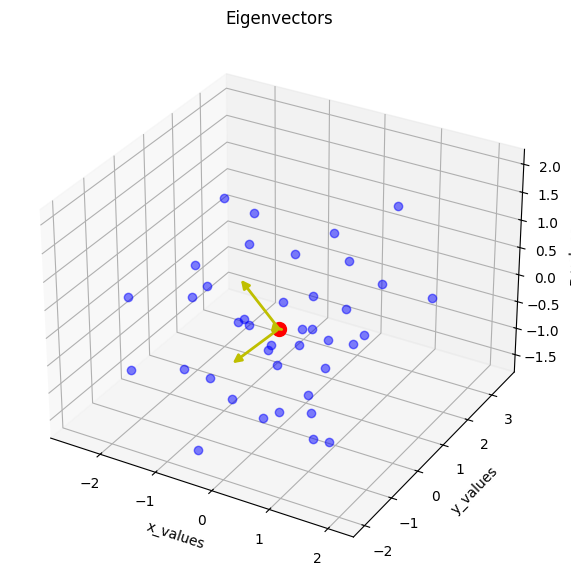

In [55]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch  # 2-D arrow maker class


class Arrow3D(FancyArrowPatch):  # making custom class, and inherite FancyArrowPatch class

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        return np.min(zs3d)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, ax.get_proj()
        )

        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)


fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# plotting points
ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=6,
    color='blue',
    alpha=0.5
)

# mean point
ax.plot(
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red'
)

# eigen vectors
for v in eigen_vectors.T:  # Transpose of eigen_vectors

    a = Arrow3D(
        [df['feature1'].mean(), df['feature1'].mean() + v[0]],  # Passing starting, and ending point of arrow
        [df['feature2'].mean(), df['feature2'].mean() + v[1]],
        [df['feature3'].mean(), df['feature3'].mean() + v[2]],
        mutation_scale=12,  # Head size of arrow
        lw=2,  # Line width of arrow
        arrowstyle="-|>",  # Arrow shape
        color="y"  #  Arrow colour
    )

    ax.add_artist(a)  # Added this arrow to axis

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

### Transforming df from 3-D to 2-D

In [57]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [56]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [58]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# Shape of matrices (40,3), (3,2)

In [60]:
type(transformed_df)

numpy.ndarray

In [61]:
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])

In [62]:
new_df.sample(2)

,PC1,PC2
20,-0.069178,-0.130994
24,0.202775,0.091815


In [65]:
new_df['target'] = df['target']
new_df.sample(4)

,PC1,PC2,target
24,0.202775,0.091815,0
17,-0.478444,0.774372,1
37,-0.997408,0.778938,0
14,-0.872205,0.530675,1


### Visualising new 2-D data

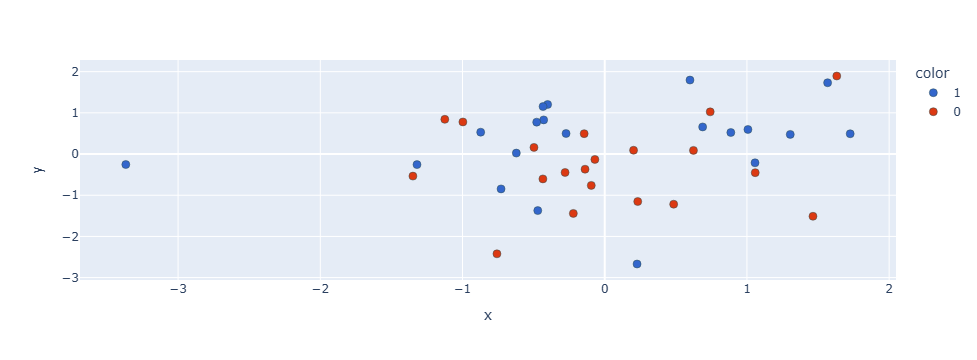

In [70]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=8,
                              line=dict(width=0.5,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()